In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, PolynomialFeatures
from sklearn.linear_model    import LinearRegression, Ridge, LogisticRegression
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_squared_error, r2_score, accuracy_score

In [6]:
df = pd.read_csv("F://Ml-Projects//Data//University//cleaned_students_record.csv" , index_col=False)
df.drop(columns=["Unnamed: 0"] , inplace=True)
df

,attendance_pct,mid_score,assignments_submitted,study_hours_per_week,lab_score,gpa,passed
0,73.05,21.1,3,14.0,9.6,1.88,0
1,61.90,35.6,9,22.3,21.8,2.91,1
2,61.20,20.7,9,11.6,21.9,3.03,1
3,73.05,31.2,6,21.6,16.2,2.37,1
4,73.80,34.2,9,14.8,20.2,3.12,1
...,...,...,...,...,...,...,...
194,100.00,40.8,4,8.2,13.8,2.87,1
195,41.00,24.8,4,13.3,21.5,2.33,1
196,73.05,-5.0,7,19.1,16.4,2.16,1
197,100.00,19.9,2,13.0,15.2,2.83,1


In [11]:
all = df.drop(columns="gpa").columns
required = "gpa"


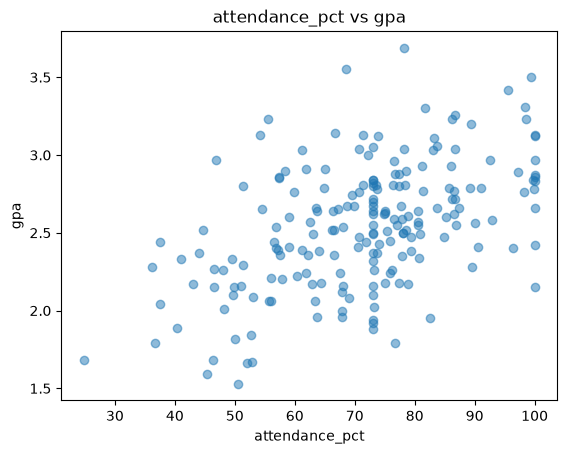

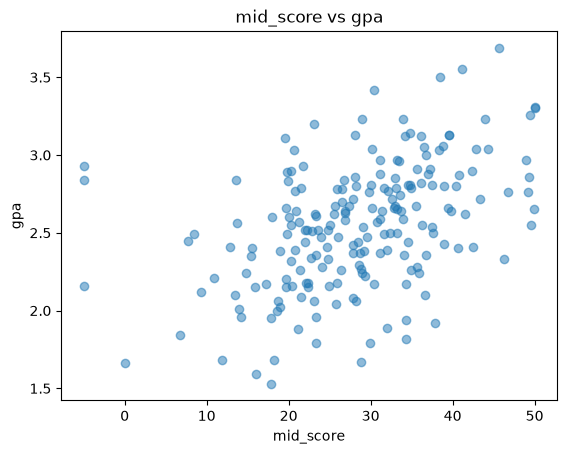

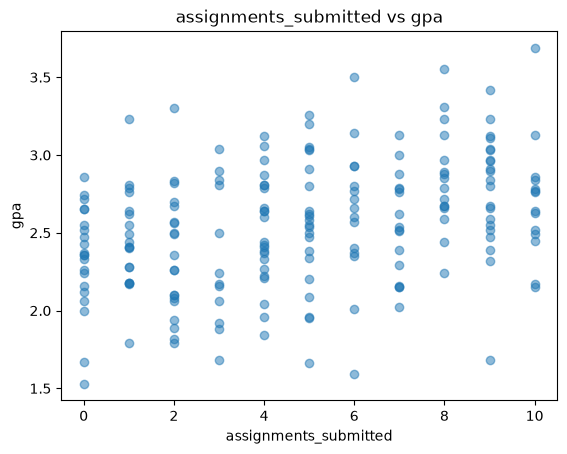

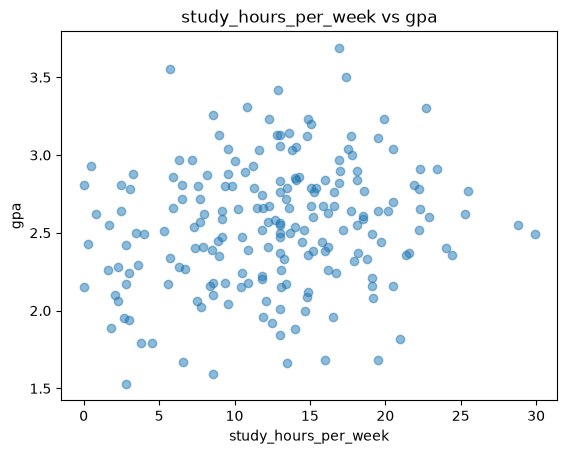

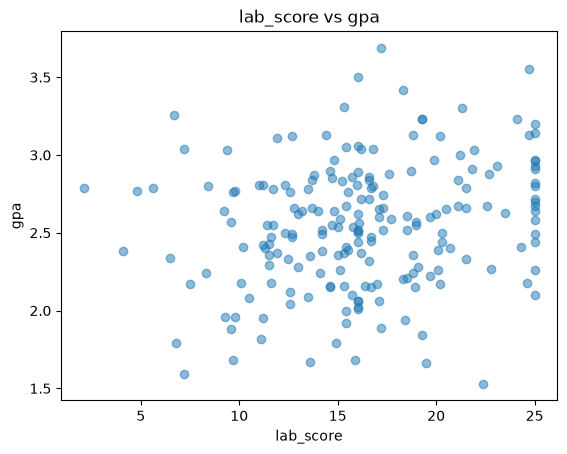

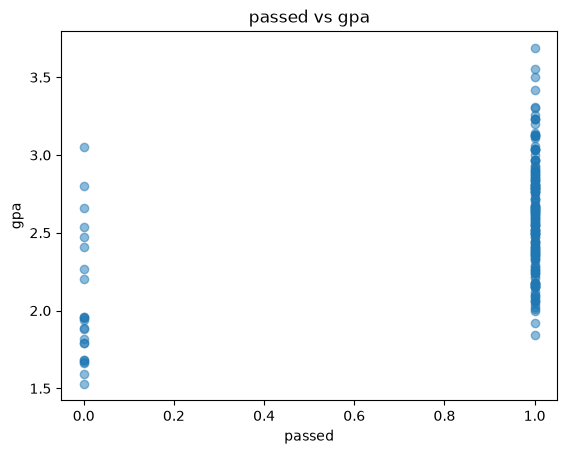

In [12]:
for col in all:
    plt.scatter(df[col] , df[required] , alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(required)
    plt.title(f"{col} vs {required}")
    plt.show()

In [13]:
x = df.drop(columns=["gpa"])
y = df["gpa"]

x_train , x_temp , y_train , y_temp = train_test_split(x , y , test_size=0.30 , random_state=42)
x_val , x_test , y_val , y_test = train_test_split(x_temp , y_temp , test_size=0.50 , random_state=42)

In [15]:
linear_pipe = Pipeline([
    ("scale" , StandardScaler()),
    ("model" , LinearRegression()),
])

linear_pipe.fit(x_train,y_train)

y_pred_train = linear_pipe.predict(x_train)
y_pred_val = linear_pipe.predict(x_val)

print("Errors")
print(f"Rmse in the training : {np.sqrt(mean_squared_error(y_train , y_pred_train)):.4f}")
print(f"Rmse in the value : {np.sqrt(mean_squared_error(y_val , y_pred_val)):.4f}")
print(f"R2 : {r2_score(y_val , y_pred_val):.4f}")

Errors
Rmse in the training : 0.2402
Rmse in the value : 0.2135
R2 : 0.6774


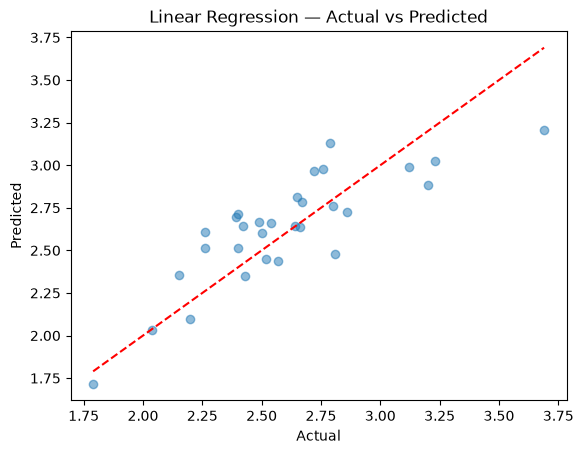

In [16]:
plt.scatter(y_val, y_pred_val, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()], 'r--')   
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression — Actual vs Predicted')
plt.show()
